# DiD Analysis of EU Accession on Gini Index

### Q4. Did poverty headcount ($3/day PPP) fall more rapidly in EU entrants?

- **Purpose:** Distributional effects.  
- **Plot:** *Percent-change bars* (2000→latest) with bootstrap CIs.  
- **Method:** **FE OLS** on Δ poverty (first difference), controls = GDPpc growth + unemployment.  
- **Test:** DiD on poverty change; $H_0:\beta=0$.  
- **Expected:** Larger decline in entrants.  
- **Pitfall:** Missingness—interpolate ≤ 2-year gaps.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

rng = np.random.default_rng(42)
sns.set(style="ticks")

# Define and create output directory at the start
output_dir = Path("reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

## 1. Load & Transform Data

In [2]:
PATH = Path("../data/proceed/filtered_indicators.csv")
df_wide = pd.read_csv(PATH)

# --- Melt from wide to long format ---
year_cols = [c for c in df_wide.columns if c.isdigit()]
df_long = df_wide.melt(
    id_vars=["Country_Name", "Country_Code", "Indicator_Name", "Indicator_Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="value"
).rename(columns={
    "Country_Name": "country",
    "Country_Code": "country_code",
    "Indicator_Name": "indicator"
})
df_long["year"] = pd.to_numeric(df_long["year"])

# --- Pivot to create a country-year panel ---
df = df_long.pivot_table(
    index=["country", "country_code", "year"],
    columns="indicator",
    values="value"
).reset_index()

# --- Define EU entrants and control group ---
EU_ENTRANTS = ["Poland", "Czechia", "Slovak Republic"]
CONTROL_GROUP = ["Russian Federation", "Ukraine", "Belarus"]
ACCESSION_YEAR = 2004

df = df[df["country"].isin(EU_ENTRANTS + CONTROL_GROUP)].copy()
df["eu_entrant"] = df["country"].isin(EU_ENTRANTS).astype(int)

# --- Create Treatment Variables ---
df["post"] = 0
mask_eu = df["eu_entrant"] == 1
df.loc[mask_eu, "post"] = (df.loc[mask_eu, "year"] >= ACCESSION_YEAR).astype(int)
df["treat"] = df["eu_entrant"] * df["post"]

# Rename columns to be more script-friendly
df = df.rename(columns={
    "Income share held by lowest 20%": "income_share_lowest20",
    "Control of Corruption: Estimate": "corruption_control",
    "Government Effectiveness: Estimate": "gov_effectiveness"
})

# Ensure numeric types
for col in ["income_share_lowest20", "corruption_control", "gov_effectiveness"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(["country", "year"])
df.head()

indicator,country,country_code,year,corruption_control,Gini index,gov_effectiveness,Income share held by highest 20%,income_share_lowest20,Net migration,"Patent applications, residents",Political Stability and Absence of Violence/Terrorism: Estimate,Regulatory Quality: Estimate,Rule of Law: Estimate,Voice and Accountability: Estimate,eu_entrant,post,treat
0,Belarus,BLR,1960,NaN,NaN,NaN,NaN,NaN,-27382.0,NaN,NaN,NaN,NaN,NaN,0,0,0
1,Belarus,BLR,1961,NaN,NaN,NaN,NaN,NaN,-26780.0,NaN,NaN,NaN,NaN,NaN,0,0,0
2,Belarus,BLR,1962,NaN,NaN,NaN,NaN,NaN,-32996.0,NaN,NaN,NaN,NaN,NaN,0,0,0
3,Belarus,BLR,1963,NaN,NaN,NaN,NaN,NaN,-28653.0,NaN,NaN,NaN,NaN,NaN,0,0,0
4,Belarus,BLR,1964,NaN,NaN,NaN,NaN,NaN,-17837.0,NaN,NaN,NaN,NaN,NaN,0,0,0


## 2. Interpolate Missing Data

In [3]:
# Interpolate <=2-year gaps (within each country)
def interp_with_rule(g, cols=("income_share_lowest20", "corruption_control", "gov_effectiveness")):
    g = g.sort_values("year").copy()
    for col in cols:
        if col not in g.columns: continue
        g[col] = g[col].interpolate(limit=2, limit_direction="both", limit_area='inside')
    return g

df = df.groupby("country", group_keys=False).apply(interp_with_rule)

/tmp/ipykernel_322109/1900296350.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("country", group_keys=False).apply(interp_with_rule)


## 3. Calculate First Differences

In [4]:
def within_diff(g):
    g = g.sort_values("year").copy()
    g["d_income_share_lowest20"] = g["income_share_lowest20"].diff()
    g["d_corruption"] = g["corruption_control"].diff()
    return g

df = df.groupby("country", group_keys=False).apply(within_diff)

# Add this line to prepare the dataframe for the next step
dfm = df.dropna(subset=["d_income_share_lowest20", "d_corruption", "treat"]).copy()

/tmp/ipykernel_322109/1192840057.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("country", group_keys=False).apply(within_diff)


## 4. Difference-in-Differences Regression

In [5]:
if not df.empty:
    # Reset index to ensure alignment after dropna
    dfm = df.reset_index(drop=True)

    # year fixed effects via dummies
    year_dummies = pd.get_dummies(dfm["year"].astype(int), prefix="y", drop_first=True, dtype=int)
    X = pd.concat([dfm[["treat", "d_corruption"]], year_dummies], axis=1)
    X = sm.add_constant(X, has_constant='add')
    y = dfm["d_income_share_lowest20"]

    # Ensure all columns are numeric before fitting
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')
    
    # Drop any rows that might have become NaN during conversion
    combined = pd.concat([y, X], axis=1).dropna()
    y = combined.iloc[:, 0]
    X = combined.iloc[:, 1:]

    res = sm.OLS(y, X, missing="drop").fit(cov_type="cluster", cov_kwds={"groups": df.loc[X.index, "country_code"]})
    beta, se, pval = res.params.get("treat", np.nan), res.bse.get("treat", np.nan), res.pvalues.get("treat", np.nan)
    print("--- DiD Results for Change in Income Share (Lowest 20%) ---")
    print(res.summary().as_text())

    # Tidy table
    tbl = (
        pd.DataFrame({"term": res.params.index, "beta": res.params.values,
                      "se": res.bse.values, "pval": res.pvalues.values})
        .assign(ci_lo=lambda d: d["beta"] - 1.96 * d["se"],
                ci_hi=lambda d: d["beta"] + 1.96 * d["se"])
    )
    
    # Save the table using the predefined output_dir
    tbl.to_csv(output_dir / "did_income_share_table.csv", index=False)
    print(f"\nDiD β (treat): {beta:.3f} (SE {se:.3f}), p={pval:.3g}.")

else:
    print("DataFrame is empty after processing. Cannot run regression.")
    beta, se, pval = np.nan, np.nan, np.nan

--- DiD Results for Change in Income Share (Lowest 20%) ---
                               OLS Regression Results                              
Dep. Variable:     d_income_share_lowest20   R-squared:                       0.152
Model:                                 OLS   Adj. R-squared:                 -0.043
Method:                      Least Squares   F-statistic:                    0.1935
Date:                     Tue, 28 Oct 2025   Prob (F-statistic):              0.952
Time:                             18:39:49   Log-Likelihood:                -41.020
No. Observations:                      145   AIC:                             138.0
Df Residuals:                          117   BIC:                             221.4
Df Model:                               27                                         
Covariance Type:                   cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------

/home/master/Documents/competitions/cirsDataSet/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 66, but rank is 5
  warnings.warn('covariance of constraints does not have full '


## 5. Plotting: Grouped Percentage Change

/tmp/ipykernel_322109/4043843789.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"pct_change": pct_change_2000_latest(g)}))


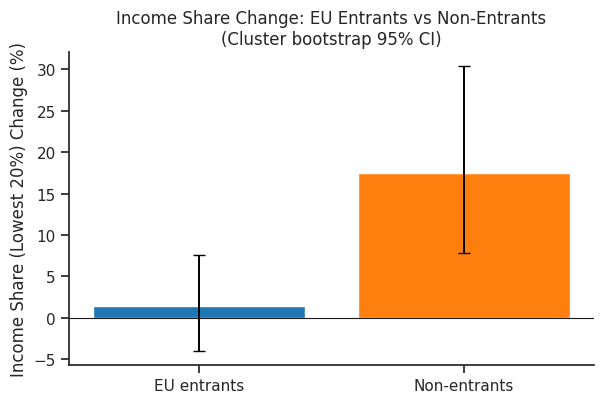

In [6]:
def pct_change_2000_latest(g):
    g = g.sort_values("year")
    g2000 = g[g["year"] >= 2000].dropna(subset=['income_share_lowest20'])
    if g2000.empty: return np.nan
    
    latest_val = g.dropna(subset=['income_share_lowest20']).iloc[-1]["income_share_lowest20"]
    t0 = g2000.iloc[0]["income_share_lowest20"]
    
    if pd.isna(t0) or pd.isna(latest_val) or t0 == 0: return np.nan
    return 100 * (latest_val - t0) / t0

country_changes = (
    df.groupby(["country", "eu_entrant"])
      .apply(lambda g: pd.Series({"pct_change": pct_change_2000_latest(g)}))
      .reset_index()
      .dropna()
)

def cluster_bootstrap_means(df_country, n_boot=2000):
    means = {}
    for label, grp in [("EU entrants", 1), ("Non-entrants", 0)]:
        sub = df_country[df_country["eu_entrant"] == grp]
        ctry = sub["country"].unique()
        if ctry.size == 0:
            means[label] = np.array([np.nan])
            continue
        draws = []
        for _ in range(n_boot):
            sample_countries = rng.choice(ctry, size=ctry.size, replace=True)
            m = sub[sub["country"].isin(sample_countries)]["pct_change"].mean()
            draws.append(m)
        means[label] = np.array(draws)
    return means

if not country_changes.empty:
    boots = cluster_bootstrap_means(country_changes, n_boot=1500)

    def mean_ci(a):
        return np.nanmean(a), np.nanpercentile(a, 2.5), np.nanpercentile(a, 97.5)

    rows = []
    for label, arr in boots.items():
        m, lo, hi = mean_ci(arr)
        rows.append({"group": label, "mean": m, "lo": lo, "hi": hi})
    plot_df = pd.DataFrame(rows)

    # Plot
    fig, ax = plt.subplots(figsize=(6.2, 4.2))
    colors = {"EU entrants": "#1f77b4", "Non-entrants": "#ff7f0e"}
    ax.bar(plot_df["group"], plot_df["mean"], color=[colors.get(g, 'gray') for g in plot_df["group"]])
    ax.errorbar(plot_df["group"], plot_df["mean"],
                yerr=[plot_df["mean"] - plot_df["lo"], plot_df["hi"] - plot_df["mean"]],
                fmt="none", ecolor="black", capsize=4, lw=1.4)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_ylabel("Income Share (Lowest 20%) Change (%)")
    ax.set_title("Income Share Change: EU Entrants vs Non-Entrants\n(Cluster bootstrap 95% CI)")
    sns.despine()
    plt.tight_layout()
    # Use the predefined output_dir to save the figure
    plt.savefig(output_dir / "income_share_change_bars.png", dpi=220)
    plt.show()
else:
    print("\nNot enough data to create the percentage change plot.")

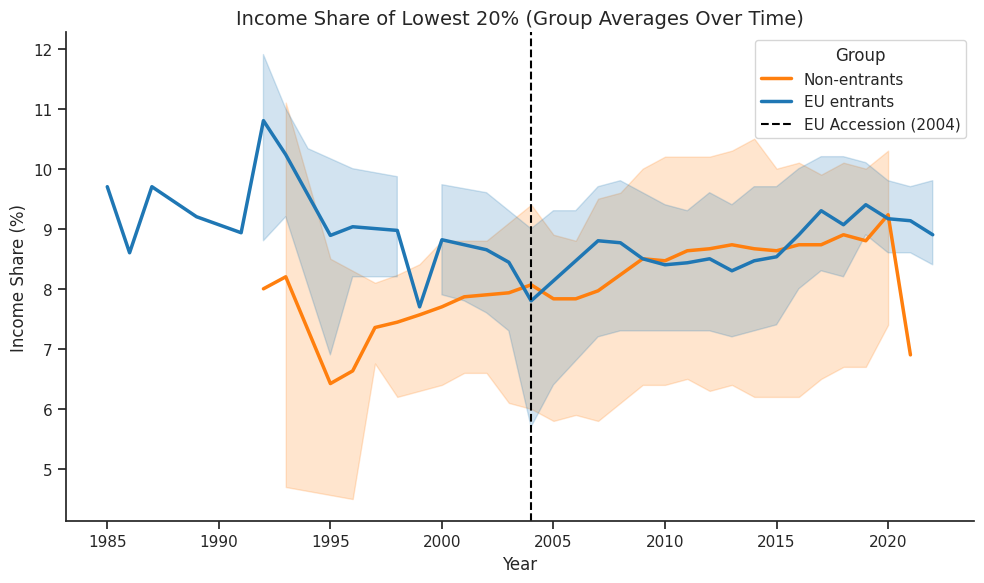

In [15]:
# Create a new cell for this plot

# --- Plotting Group Trends Over Time ---
fig, ax = plt.subplots(figsize=(10, 6))

# Create a temporary column for clearer legend labels
df['Group'] = df['eu_entrant'].map({0: 'Non-entrants', 1: 'EU entrants'})
palette = {'Non-entrants': "#ff7f0e", 'EU entrants': "#1f77b4"}

# Plot the average income share for each group over time
sns.lineplot(
    data=df,
    x='year',
    y='income_share_lowest20',
    hue='Group',
    palette=palette,
    ax=ax,
    lw=2.5
)

# Add a vertical line for the EU accession year
ax.axvline(x=ACCESSION_YEAR, color='black', linestyle='--', lw=1.5, label=f'EU Accession ({ACCESSION_YEAR})')

# Formatting
ax.set_title('Income Share of Lowest 20% (Group Averages Over Time)', fontsize=14)
ax.set_ylabel('Income Share (%)')
ax.set_xlabel('Year')
ax.legend(title='Group')
sns.despine()
plt.tight_layout()
plt.show()

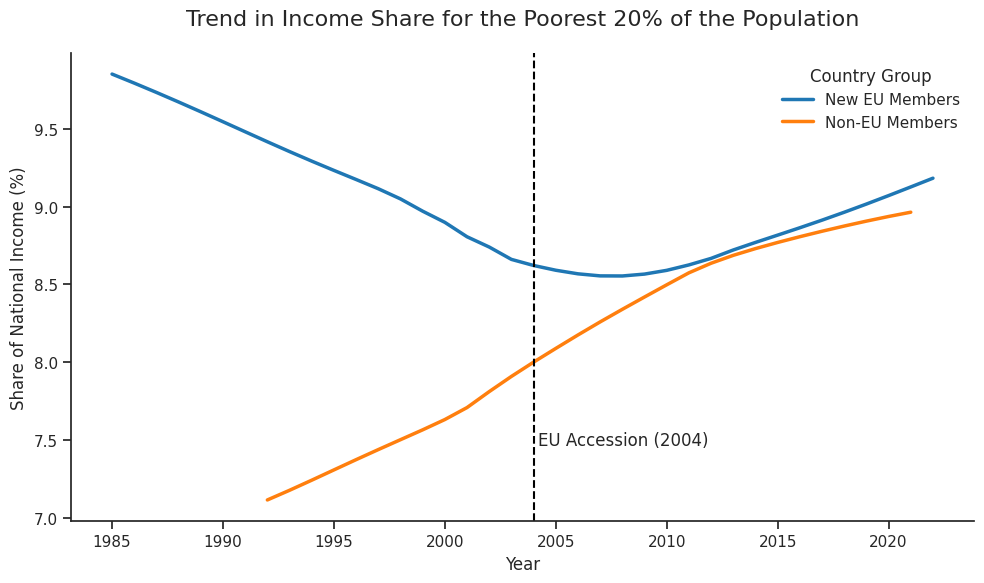

In [23]:
# --- A More Clear Visualization for a General Audience ---
fig, ax = plt.subplots(figsize=(10, 6))

# Use a mapping for more descriptive labels in the legend
group_labels = {0: 'Non-EU Members', 1: 'New EU Members'}
df['Group_Descriptive'] = df['eu_entrant'].map(group_labels)
palette = {'Non-EU Members': "#ff7f0e", 'New EU Members': "#1f77b4"}

# Plot a smoothed trend line for each group
# We use regplot with lowess=True for smoothing and ci=None to remove the shaded area.
for name, group_df in df.groupby('Group_Descriptive'):
    sns.regplot(
        data=group_df,
        x='year',
        y='income_share_lowest20',
        ax=ax,
        lowess=True,      # This creates the smooth line
        ci=None,          # This removes the confusing shaded confidence interval
        scatter=False,    # We hide the individual data points to reduce clutter
        label=name,
        color=palette[name],
        line_kws={'lw': 2.5}
    )

# --- Formatting ---
# Add the vertical line for the EU accession year, but without a label for the legend
ax.axvline(x=ACCESSION_YEAR, color='black', linestyle='--', lw=1.5)

# Add the text label directly onto the plot next to the line
# We add a small offset to the x-position and rotate the text for a clean look.
ax.text(ACCESSION_YEAR + 0.2, 7.5, f'EU Accession ({ACCESSION_YEAR})', verticalalignment='center')

# Use more descriptive labels and title
ax.set_title(
    'Trend in Income Share for the Poorest 20% of the Population',
    fontsize=16,
    pad=20
)
ax.set_ylabel('Share of National Income (%)')
ax.set_xlabel('Year')

# Improve the legend
ax.legend(title='Country Group', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [16]:
df.head()

indicator,country,country_code,year,corruption_control,Gini index,gov_effectiveness,Income share held by highest 20%,income_share_lowest20,Net migration,"Patent applications, residents",...,treat,d_income_share_lowest20,d_corruption,top_bottom_ratio,sum_top_bottom,top20,bottom20,middle60,Group,Group_Descriptive
0,Belarus,BLR,1960,NaN,NaN,NaN,NaN,NaN,-27382.0,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Non-EU Members,Non-EU Members
1,Belarus,BLR,1961,NaN,NaN,NaN,NaN,NaN,-26780.0,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Non-EU Members,Non-EU Members
2,Belarus,BLR,1962,NaN,NaN,NaN,NaN,NaN,-32996.0,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Non-EU Members,Non-EU Members
3,Belarus,BLR,1963,NaN,NaN,NaN,NaN,NaN,-28653.0,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Non-EU Members,Non-EU Members
4,Belarus,BLR,1964,NaN,NaN,NaN,NaN,NaN,-17837.0,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,100.0,Non-EU Members,Non-EU Members


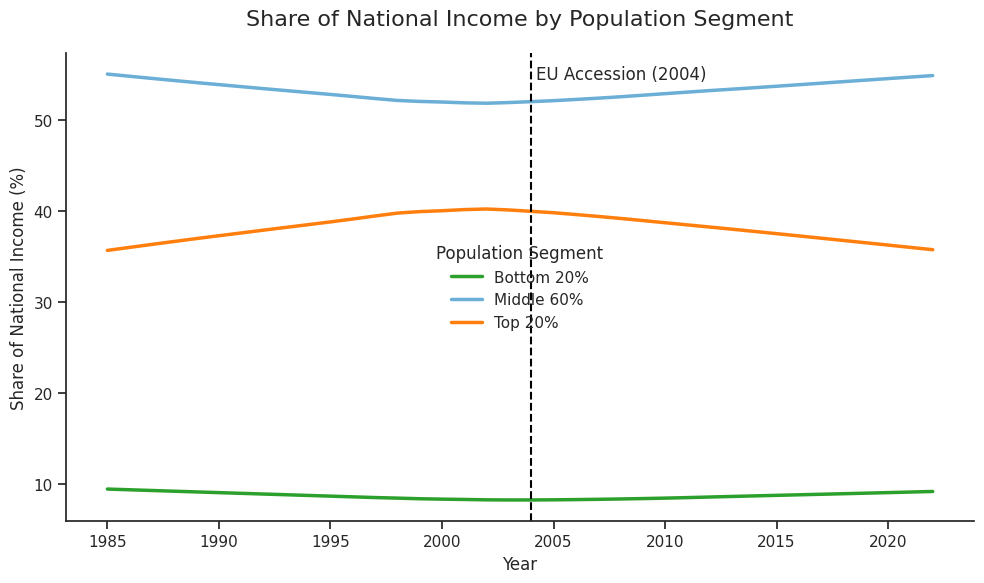

In [18]:
# ...existing code...
shares_long = (
    df.assign(
        bottom20=pd.to_numeric(df["income_share_lowest20"], errors="coerce"),
        top20=pd.to_numeric(df["Income share held by highest 20%"], errors="coerce")
    )
    .assign(middle60=lambda d: 100 - d["bottom20"] - d["top20"])
    [["year", "eu_entrant", "bottom20", "middle60", "top20"]]
    .melt(id_vars=["year", "eu_entrant"], var_name="segment", value_name="share")
    .dropna()
    .groupby(["eu_entrant", "year", "segment"], as_index=False)["share"].mean()
    .assign(
        group=lambda d: d["eu_entrant"].map({0: "Non‑EU Members", 1: "New EU Members"}),
        segment=lambda d: d["segment"].map({"bottom20": "Bottom 20%", "middle60": "Middle 60%", "top20": "Top 20%"})
    )
)

fig, ax = plt.subplots(figsize=(10, 6))
palette = {"Bottom 20%": "#2ca02c", "Middle 60%": "#6baed6", "Top 20%": "#ff7f0e"}

for seg, g in shares_long.groupby("segment"):
    sns.regplot(
        data=g,
        x="year",
        y="share",
        ax=ax,
        lowess=True,
        ci=None,
        scatter=False,
        label=seg,
        color=palette[seg],
        line_kws={"lw": 2.5}
    )

ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.5)
ax.text(ACCESSION_YEAR + 0.2, 55, f"EU Accession ({ACCESSION_YEAR})", va="center")

ax.set_title("Share of National Income by Population Segment", fontsize=16, pad=20)
ax.set_ylabel("Share of National Income (%)")
ax.set_xlabel("Year")
ax.legend(title="Population Segment", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

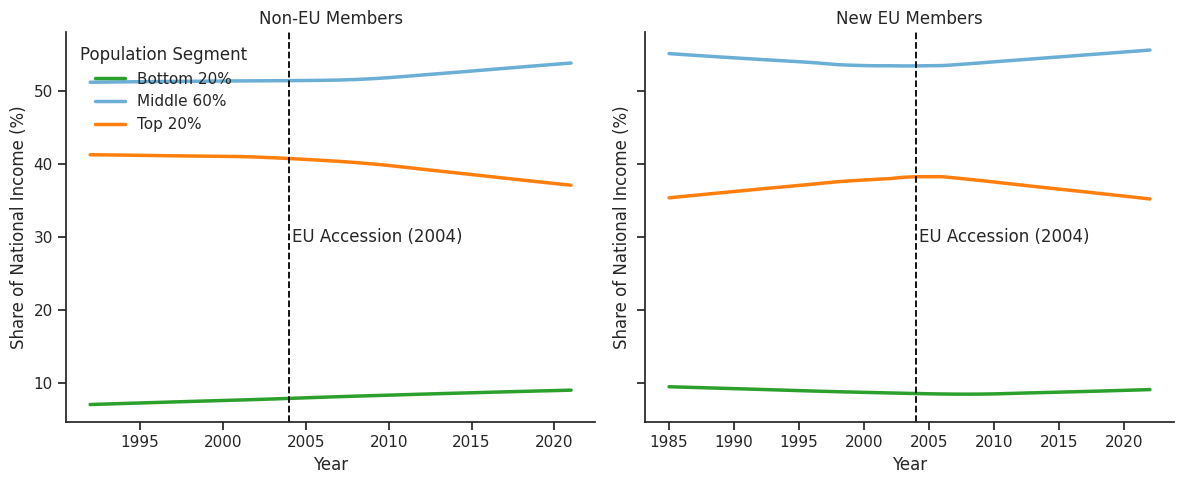

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
palette = {"Bottom 20%": "#2ca02c", "Middle 60%": "#6baed6", "Top 20%": "#ff7f0e"}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    for seg, g in subset.groupby("segment"):
        sns.regplot(
            data=g,
            x="year",
            y="share",
            lowess=True,
            ci=None,
            scatter=False,
            label=seg,
            color=palette[seg],
            line_kws={"lw": 2.5},
            ax=ax,
        )
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.3)
    ax.text(ACCESSION_YEAR + 0.2, 30, f"EU Accession ({ACCESSION_YEAR})", va="center")
    ax.set_title(grp)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of National Income (%)")

axes[0].legend(title="Population Segment", frameon=False, loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

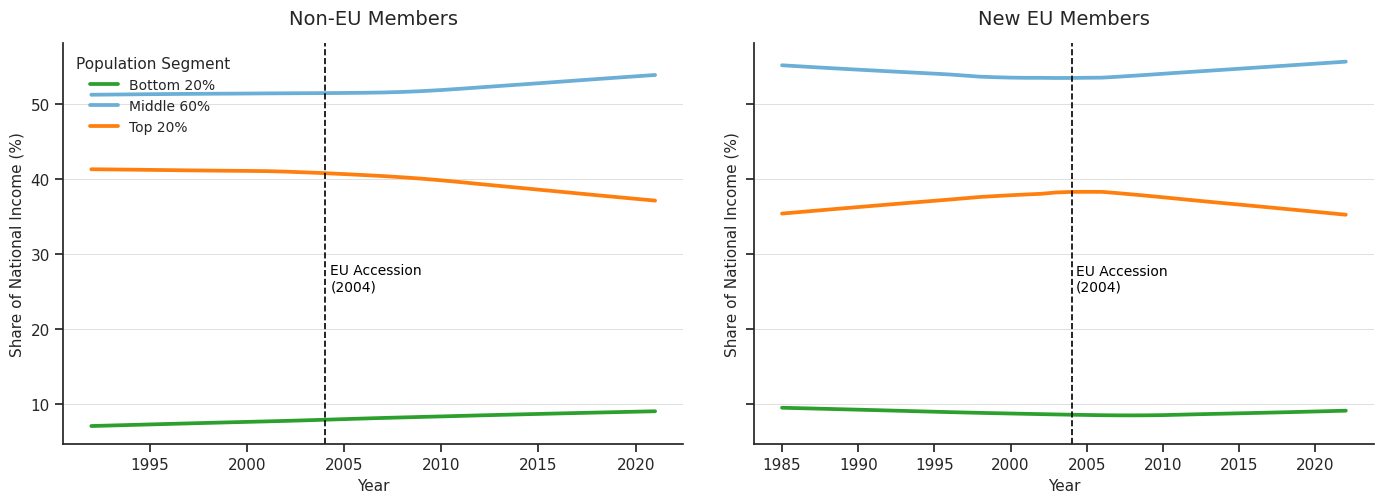

In [25]:
# ...existing code...
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
palette = {"Bottom 20%": "#2ca02c", "Middle 60%": "#6baed6", "Top 20%": "#ff7f0e"}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    for seg, g in subset.groupby("segment"):
        sns.regplot(
            data=g,
            x="year",
            y="share",
            lowess=True,
            ci=None,
            scatter=False,
            label=seg,
            color=palette[seg],
            line_kws={"lw": 2.7},
            ax=ax,
        )
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.2)
    ax.text(ACCESSION_YEAR + 0.3, ax.get_ylim()[0] + 20, f"EU Accession\n({ACCESSION_YEAR})",
            va="bottom", ha="left", fontsize=10, color="black")
    ax.set_title(f"{grp}", fontsize=14, pad=14)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Share of National Income (%)", fontsize=11)
    ax.grid(axis="y", color="0.85", lw=0.6)
    ax.set_axisbelow(True)

axes[0].legend(title="Population Segment", frameon=False, loc="upper left", fontsize=10, title_fontsize=11)
sns.despine()
plt.tight_layout(w_pad=2.5)
plt.show()

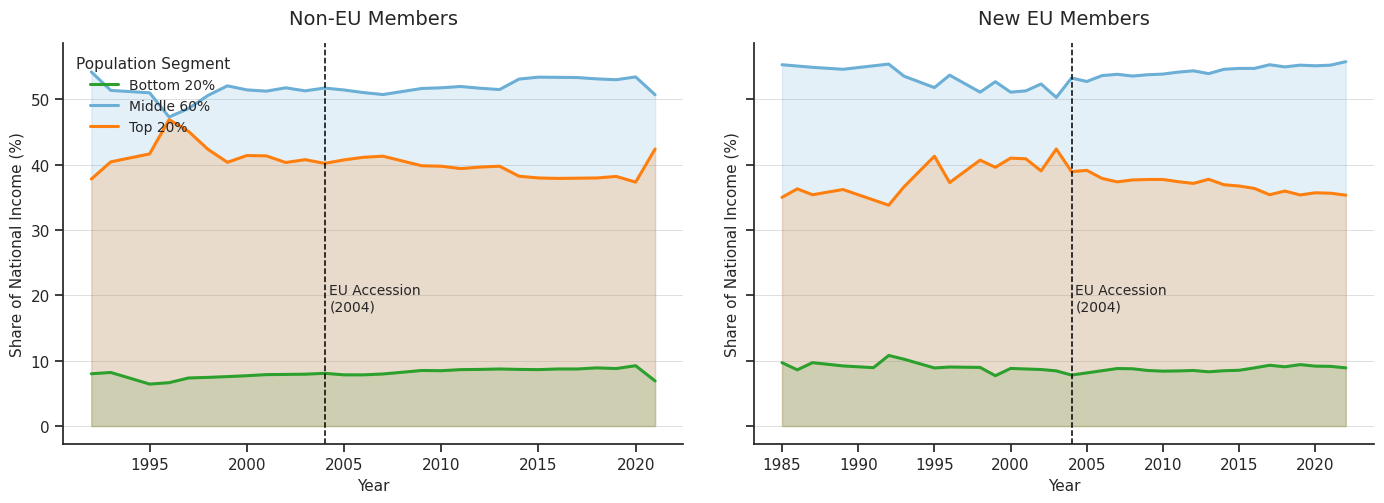

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
palette = {"Bottom 20%": "#2ca02c", "Middle 60%": "#6baed6", "Top 20%": "#ff7f0e"}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    for seg, g in subset.groupby("segment"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["share"], color=palette[seg], lw=2.2, label=seg)
        ax.fill_between(g["year"], g["share"], color=palette[seg], alpha=0.18)
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.1)
    ax.text(ACCESSION_YEAR + 0.25, ax.get_ylim()[0] + 20,
            f"EU Accession\n({ACCESSION_YEAR})", va="bottom", ha="left", fontsize=10)
    ax.set_title(grp, fontsize=14, pad=14)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Share of National Income (%)", fontsize=11)
    ax.grid(axis="y", color="0.85", lw=0.6)
    ax.set_axisbelow(True)

axes[0].legend(title="Population Segment", frameon=False, loc="upper left", fontsize=10, title_fontsize=11)
sns.despine()
plt.tight_layout(w_pad=2.5)
plt.show()

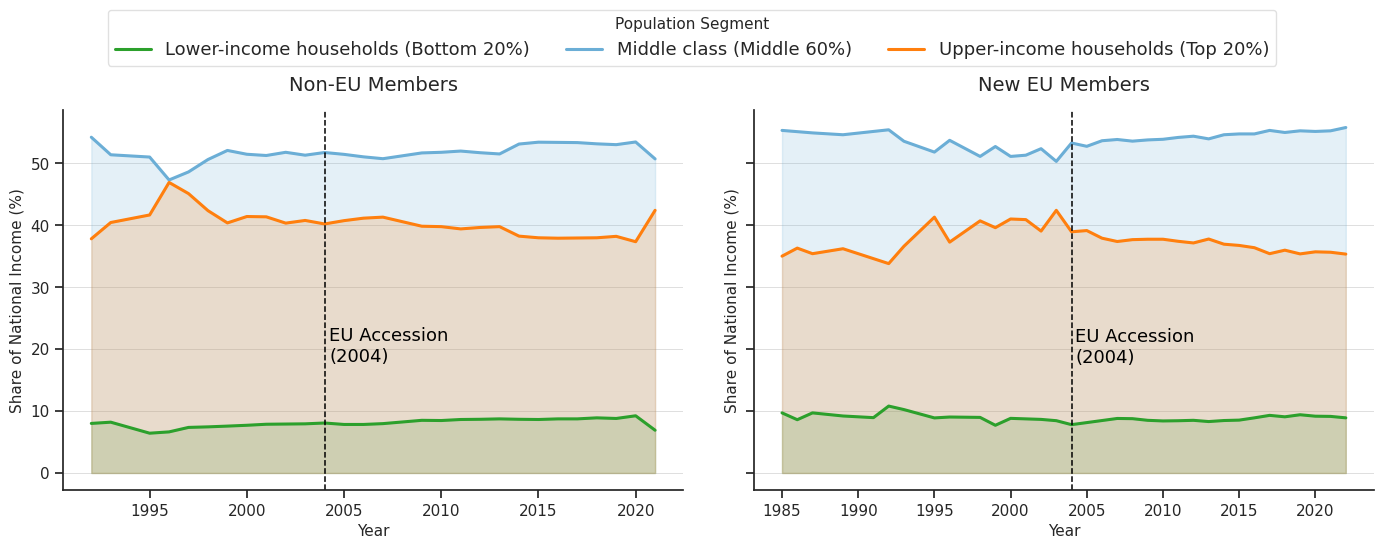

In [ ]:
shares_long = (
    df.assign(
        bottom20=pd.to_numeric(df["income_share_lowest20"], errors="coerce"),
        top20=pd.to_numeric(df["Income share held by highest 20%"], errors="coerce")
    )
    .assign(middle60=lambda d: 100 - d["bottom20"] - d["top20"])
    [["year", "eu_entrant", "bottom20", "middle60", "top20"]]
    .melt(id_vars=["year", "eu_entrant"], var_name="segment", value_name="share")
    .dropna()
    .groupby(["eu_entrant", "year", "segment"], as_index=False)["share"].mean()
    .assign(
        group=lambda d: d["eu_entrant"].map({0: "Non‑EU Members", 1: "New EU Members"}),
        segment=lambda d: d["segment"].map({
            "bottom20": "Lower-income households (Bottom 20%)",
            "middle60": "Middle class (Middle 60%)",
            "top20": "Upper-income households (Top 20%)"
        })
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
palette = {
    "Lower-income households (Bottom 20%)": "#2ca02c",
    "Middle class (Middle 60%)": "#6baed6",
    "Upper-income households (Top 20%)": "#ff7f0e"
}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    for seg, g in subset.groupby("segment"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["share"], color=palette[seg], lw=2.2, label=seg)
        ax.fill_between(g["year"], g["share"], color=palette[seg], alpha=0.18)
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.1)
    ax.text(ACCESSION_YEAR + 0.25, ax.get_ylim()[0] + 20,
            f"EU Accession\n({ACCESSION_YEAR})", va="bottom", ha="left", fontsize=13, color="black")
    ax.set_title(grp, fontsize=14, pad=14)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Share of National Income (%)", fontsize=11)
    ax.grid(axis="y", color="0.85", lw=0.6)
    ax.set_axisbelow(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Population Segment",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="0.85",
    title_fontsize=11,
    fontsize=13
)

sns.despine()
plt.tight_layout(w_pad=2.5, rect=(0, 0, 1, 0.96))
plt.show()

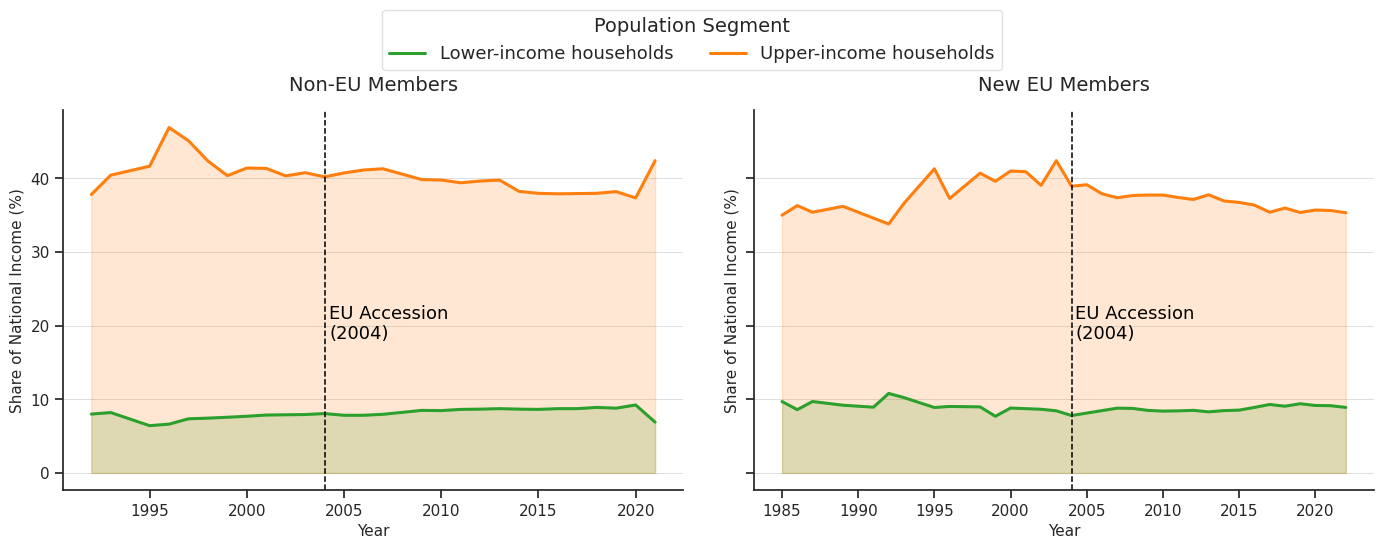

In [68]:
shares_long = (
    df.assign(
        bottom20=pd.to_numeric(df["income_share_lowest20"], errors="coerce"),
        top20=pd.to_numeric(df["Income share held by highest 20%"], errors="coerce")
    )
    [["year", "eu_entrant", "bottom20", "top20"]]
    .melt(id_vars=["year", "eu_entrant"], var_name="segment", value_name="share")
    .dropna()
    .groupby(["eu_entrant", "year", "segment"], as_index=False)["share"].mean()
    .assign(
        group=lambda d: d["eu_entrant"].map({0: "Non‑EU Members", 1: "New EU Members"}),
        segment=lambda d: d["segment"].map({
            "bottom20": "Lower-income households",
            "top20": "Upper-income households"
        })
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
palette = {
    "Lower-income households": "#2ca02c",
    "Upper-income households": "#ff7f0e"
}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    for seg, g in subset.groupby("segment"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["share"], color=palette[seg], lw=2.2, label=seg)
        ax.fill_between(g["year"], g["share"], color=palette[seg], alpha=0.18)
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.1)
    ax.text(ACCESSION_YEAR + 0.25, ax.get_ylim()[0] + 20,
            f"EU Accession\n({ACCESSION_YEAR})", va="bottom", ha="left", fontsize=13, color="black")
    ax.set_title(grp, fontsize=14, pad=14)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Share of National Income (%)", fontsize=11)
    ax.grid(axis="y", color="0.85", lw=0.6)
    ax.set_axisbelow(True)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Population Segment",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="0.85",
    title_fontsize=14,
    fontsize=13
)

sns.despine()
plt.tight_layout(w_pad=2.5, rect=(0, 0, 1, 0.96))
plt.show()

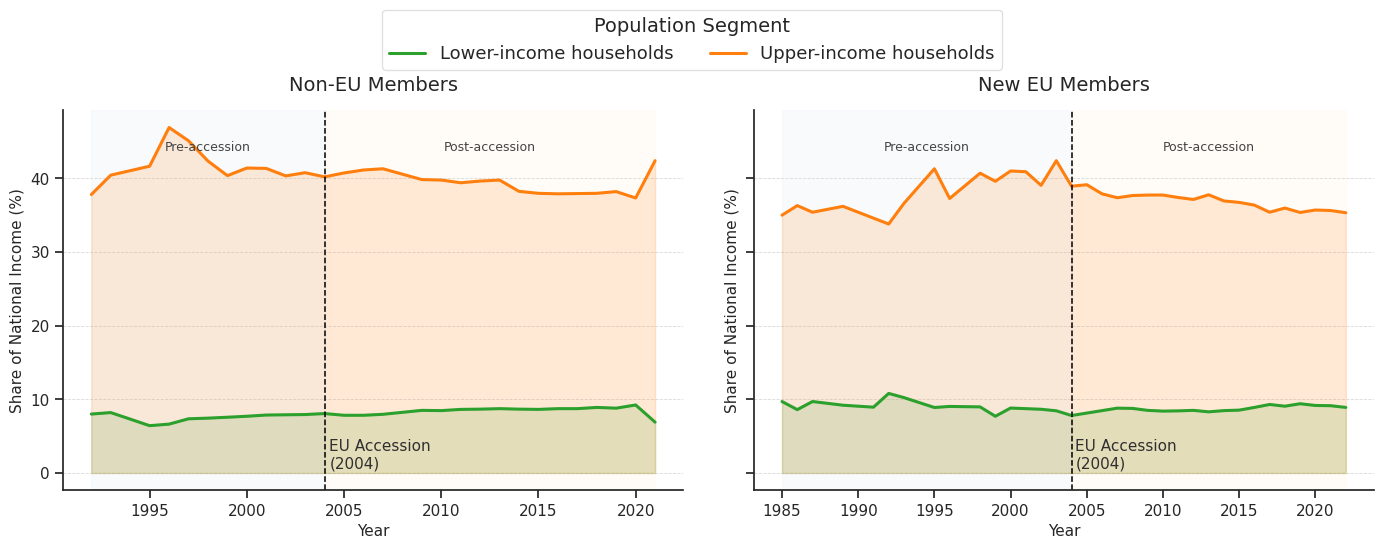

In [67]:
# ...existing code...
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
palette = {
    "Lower-income households": "#2ca02c",
    "Upper-income households": "#ff7f0e"
}

for ax, grp in zip(axes, ["Non‑EU Members", "New EU Members"]):
    subset = shares_long[shares_long["group"] == grp]
    pre_start, post_end = subset["year"].min(), subset["year"].max()
    ax.axvspan(pre_start, ACCESSION_YEAR, color="#e8eef7", alpha=0.25, zorder=0)
    ax.axvspan(ACCESSION_YEAR, post_end, color="#fff4e0", alpha=0.22, zorder=0)

    for seg, g in subset.groupby("segment"):
        g = g.sort_values("year")
        ax.plot(g["year"], g["share"], color=palette[seg], lw=2.2, label=seg)
        ax.fill_between(g["year"], g["share"], color=palette[seg], alpha=0.15)
    ax.axvline(ACCESSION_YEAR, color="black", linestyle="--", lw=1.1)

    ymin, ymax = ax.get_ylim()
    ax.text(ACCESSION_YEAR - (ACCESSION_YEAR - pre_start) / 2, ymax - (ymax - ymin) * 0.08,
            "Pre-accession", ha="center", va="top", fontsize=9, color="#444")
    ax.text(ACCESSION_YEAR + (post_end - ACCESSION_YEAR) / 2, ymax - (ymax - ymin) * 0.08,
            "Post-accession", ha="center", va="top", fontsize=9, color="#444")

    ax.text(ACCESSION_YEAR + 0.25, ymin + (ymax - ymin) * 0.05,
            f"EU Accession\n({ACCESSION_YEAR})", va="bottom", ha="left", fontsize=11, color="#2f2f2f")
    ax.set_title(grp, fontsize=14, pad=14)
    ax.set_xlabel("Year", fontsize=11)
    ax.set_ylabel("Share of National Income (%)", fontsize=11)
    ax.grid(axis="y", color="0.85", lw=0.6, linestyle="--")
    ax.set_axisbelow(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Population Segment",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="0.85",
    title_fontsize=14,
    fontsize=13
)

sns.despine()
plt.tight_layout(w_pad=2.5, rect=(0, 0, 1, 0.96))
plt.show()